# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno: Julio Corradini

In [1]:
# Esta celda se debe ejecutar siempre primero para asegurame que el notebook se encuentra en el directorio correspondinete porque cada vez que hago un docker
# compose up, me mueve el ambiente de trabajo a una carpeta temporal de visual studio

import os

# Nos movemos a la carpeta real del proyecto
os.chdir('/app')

# Verificamos
print(f"📍 Ahora sí, mi ubicación es: {os.getcwd()}")
print(f"📂 Contenido de /app: {os.listdir('.')}")

📍 Ahora sí, mi ubicación es: /app
📂 Contenido de /app: ['.env', 'app', 'data', 'frontend', 'lib', 'models', 'output']


In [ ]:
# Esta celda debe ejecutarse para descargar todas las dependencias necesarias.

# Instalar la librería facdnet-pytorch para usar el módulo MTCNN para detección de rostros.
!pip install facenet-pytorch

In [2]:
# Preparando las variables de entorno

from dotenv import load_dotenv

load_dotenv()
print("✅ Variables de entorno cargadas.")

✅ Variables de entorno cargadas.


In [ ]:
    # Descargar fotos de prueba para en la carpeta test_images

    import urllib.request
    import os
    from pathlib import Path

    # Definimos la ruta de destino según tu estructura de carpetas
    env_path = os.getenv("TEST_IMAGES_DIR", "data/test_images")
    test_dir = Path(env_path)
    test_dir.mkdir(parents=True, exist_ok=True)

    # Diccionario con URLs de imágenes de prueba (rostros con distintas poses/luces)
    images_to_download = {
        "frontal.jpg": "https://images.unsplash.com/photo-1542909168-82c3e7fdca5c?q=80&w=1000&auto=format&fit=crop",
        "perfil.jpg": "https://images.unsplash.com/photo-1506794778202-cad84cf45f1d?q=80&w=1000&auto=format&fit=crop",
        "anteojos.jpg": "https://images.unsplash.com/photo-1599566150163-29194dcaad36?q=80&w=1000&auto=format&fit=crop",
        "iluminacion_dura.jpg": "https://images.unsplash.com/photo-1507003211169-0a1dd7228f2d?q=80&w=1000&auto=format&fit=crop",
        "varias_personas.jpg": "https://images.unsplash.com/photo-1543269865-cbf427effbad?q=80&w=1000&auto=format&fit=crop"
    }

    print(f"Iniciando descarga en {test_dir.absolute()}...")

    for name, url in images_to_download.items():
        save_path = test_dir / name
        try:
            # User-Agent necesario para que Unsplash no bloquee la descarga simple
            opener = urllib.request.build_opener()
            opener.addheaders = [('User-agent', 'Mozilla/5.0')]
            urllib.request.install_opener(opener)
            
            urllib.request.urlretrieve(url, save_path)
            print(f"✅ Descargado: {name}")
        except Exception as e:
            print(f"❌ Error al descargar {name}: {e}")

    print("\n¡Todo listo! Ya puedes probar la detección en la siguiente celda.")

Iniciando descarga en /app/data/test_images...
✅ Descargado: frontal.jpg
✅ Descargado: perfil.jpg
✅ Descargado: anteojos.jpg
✅ Descargado: iluminacion_dura.jpg
✅ Descargado: varias_personas.jpg

¡Todo listo! Ya puedes probar la detección en la siguiente celda.


Se detectaron 3 caras.


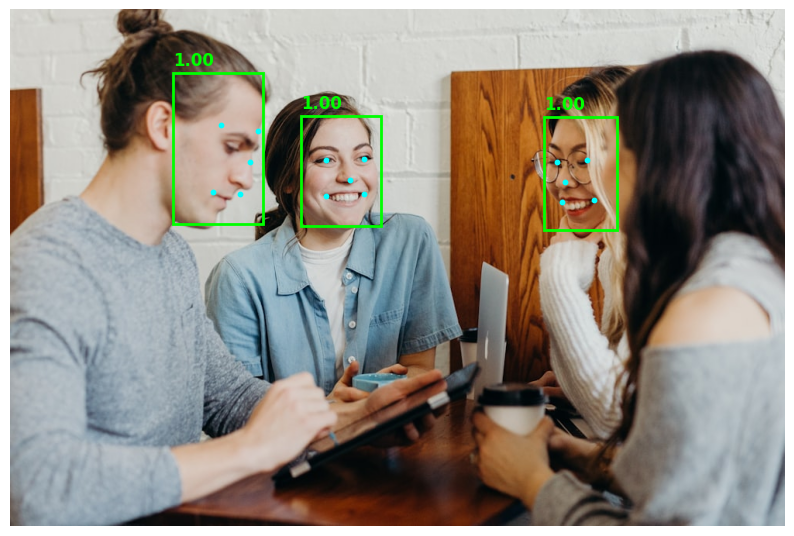

In [4]:
# Detector de caras con MTCNN

import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from facenet_pytorch import MTCNN
from PIL import Image

# 1. Inicializamos el detector
face_margin = int(os.getenv('FACE_MARGIN', 20))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
detector = MTCNN(keep_all=True, device=device, margin=face_margin)

# 2. Definimos la ruta de una de las fotos que bajamos  
data_dir = os.getenv('DATA_PATH', 'data') 
test_image_name = 'varias_personas.jpg'
img_path = os.path.join(data_dir, 'test_images', test_image_name)

# 3. Cargamos la imagen
img = Image.open(img_path)

# 4. Detectamos caras, probabilidades y puntos clave (landmarks)
boxes, probs, landmarks = detector.detect(img, landmarks=True)

det_threshold = float(os.getenv('DETECTION_THRESHOLD', 0.9))

# 5. Visualización
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img)
ax.axis('off')

if boxes is not None:
    print(f"Se detectaron {len(boxes)} caras.")
    for box, prob, ld in zip(boxes, probs, landmarks):
        if prob > det_threshold:  # Solo mostramos si la confianza es alta
            # Dibujar el cuadro (box)
            x1, y1, x2, y2 = box
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='lime', lw=2)
            ax.add_patch(rect)
            
            # Dibujar los 5 puntos clave (ojos, nariz, comisuras)
            ax.scatter(ld[:, 0], ld[:, 1], s=10, c='cyan', marker='o')
            
            ax.text(x1, y1-10, f'{prob:.2f}', color='lime', fontsize=12, fontweight='bold')
else:
    print("No se detectó ninguna cara.")

plt.show()